# 第7章 動的離散選択モデル：二段階推定と反実仮想分析

第6章で生成した中古車購入に関するシミュレーションデータを用い、
二段階推定法（行列インバージョン、有限依存性アプローチ）で構造パラメータを推定する。
さらに、EDLP（毎日低価格）や値下げの反実仮想分析を行う。

In [1]:
import numpy as np
import pandas as pd
from scipy import optimize, stats
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib
import warnings
import time
warnings.filterwarnings('ignore')

# 日本語フォント設定
for font_name in ['Hiragino Maru Gothic Pro', 'Hiragino Sans',
                   'IPAexGothic', 'Noto Sans CJK JP', 'Yu Gothic']:
    try:
        matplotlib.font_manager.findfont(font_name, fallback_to_default=False)
        plt.rcParams['font.family'] = font_name
        break
    except ValueError:
        continue

# パス設定
base_dir = Path('..')
intermediate_dir = base_dir / 'intermediate'
output_dir = base_dir / 'output'
intermediate_dir.mkdir(exist_ok=True)
output_dir.mkdir(exist_ok=True)

print("Setup complete.")


Setup complete.


## データの読み込み

In [2]:
# 第6章で生成したデータを読み込む
data_gen = pd.read_csv(intermediate_dir / 'Chap6_data.csv', index_col=0)
print(f"データサイズ: {data_gen.shape}")
data_gen.head(3)


データサイズ: (10000, 12)


,consumer,period,eps_type1_not_buy,eps_type1_buy,eps_unif,eps_price_state_unif,state_id,action,price_id,mileage_id,price,mileage
0,1,41,4.491715,2.546153,0.615910,0.083236,90,0,6,15,2.5,0.070
1,1,42,1.237423,2.096256,0.037692,0.305307,94,0,4,16,2.3,0.075
2,1,43,-0.240104,-0.028966,0.349311,0.634125,91,0,1,16,2.0,0.075


## パラメータの設定とState空間の作成

In [3]:
# パラメータの設定
theta_true = np.array([15.0, 6.0])  # theta_c, theta_p
beta = 0.95
Euler_const = -np.euler_gamma
num_choice = 2

# 状態空間の作成
price_states = np.round(np.arange(2.0, 2.6, 0.1), 1)[:6]      # [2.0, 2.1, ..., 2.5]
mileage_states = np.round(np.arange(0, 0.105, 0.005), 3)[:21]  # [0, 0.005, ..., 0.1]

num_price_states = len(price_states)      # 6
num_mileage_states = len(mileage_states)  # 21
num_states = num_price_states * num_mileage_states  # 126

state_df = pd.DataFrame({
    'state_id': np.arange(1, num_states + 1),
    'price_id': np.tile(np.arange(1, num_price_states + 1), num_mileage_states),
    'mileage_id': np.repeat(np.arange(1, num_mileage_states + 1), num_price_states),
    'price': np.tile(price_states, num_mileage_states),
    'mileage': np.repeat(mileage_states, num_price_states)
})

print(f"状態空間: {num_price_states} prices x {num_mileage_states} mileage = {num_states} states")


状態空間: 6 prices x 21 mileage = 126 states


## データの加工

In [4]:
# ラグ変数を追加
data_gen = data_gen.sort_values(['consumer', 'period']).copy()
data_gen['lag_price_id'] = data_gen.groupby('consumer')['price_id'].shift(1)
data_gen['lag_mileage_id'] = data_gen.groupby('consumer')['mileage_id'].shift(1)
data_gen['lag_action'] = data_gen.groupby('consumer')['action'].shift(1)

# 記述統計
desc = data_gen[['price', 'mileage', 'action']].describe()
print("記述統計:")
print(desc.loc[['mean', 'std', 'min', 'max']].to_string())


記述統計:
         price   mileage    action
mean  2.320460  0.043214  0.027800
std   0.154181  0.025212  0.164408
min   2.000000  0.000000  0.000000
max   2.500000  0.100000  1.000000


## 関数定義

In [5]:
def gen_mileage_trans(kappa):
    """走行距離の遷移行列を生成する（購買なし/ありの2つ）"""
    kappa_1, kappa_2 = kappa
    mat_not_buy = np.zeros((num_mileage_states, num_mileage_states))
    for i in range(num_mileage_states):
        for j in range(num_mileage_states):
            if i == j:
                mat_not_buy[i, j] = 1 - kappa_1 - kappa_2
            elif i == j - 1:
                mat_not_buy[i, j] = kappa_1
            elif i == j - 2:
                mat_not_buy[i, j] = kappa_2
    mat_not_buy[num_mileage_states - 2, num_mileage_states - 1] = kappa_1 + kappa_2
    mat_not_buy[num_mileage_states - 1, num_mileage_states - 1] = 1
    mat_buy = np.tile(mat_not_buy[0, :], (num_mileage_states, 1))
    return np.stack([mat_not_buy, mat_buy], axis=2)


def gen_price_trans(lam):
    """価格の遷移行列を生成する"""
    lambda_diag = []
    for i in range(num_price_states):
        start = i * (num_price_states - 1)
        end = start + (num_price_states - 1)
        lambda_diag.append(1 - np.sum(lam[start:end]))
    mat = np.zeros((num_price_states, num_price_states))
    idx = 0
    for i in range(num_price_states):
        for j in range(num_price_states):
            if i == j:
                mat[i, j] = lambda_diag[i]
            else:
                mat[i, j] = lam[idx]
                idx += 1
    return mat


def flow_utility(theta, state_df_local):
    """状態変数・選択肢毎の今期の効用を返す"""
    theta_c, theta_p = theta
    U_not_buy = -theta_c * state_df_local['mileage'].values
    U_buy = -theta_p * state_df_local['price'].values
    return np.column_stack([U_not_buy, U_buy])


def contraction_nfxp(theta, beta_val, G, state_df_local):
    """価値関数反復法（縮小写像） - 3次元配列G版"""
    n = len(state_df_local)
    V_old = np.zeros(n)
    U = flow_utility(theta, state_df_local)
    diff = 1000
    tol_level = 1.0e-12
    while diff > tol_level:
        EV = np.column_stack([
            G[:, :, 0] @ V_old,
            G[:, :, 1] @ V_old
        ])
        V_new = np.log(np.sum(np.exp(U + beta_val * EV), axis=1)) + Euler_const
        diff = np.max(np.abs(V_new - V_old))
        V_old = V_new.copy()
    return V_old


def policy_operator_nfxp(theta, beta_val, G, state_df_local):
    """NFXP: 価値関数からCCPを計算"""
    U = flow_utility(theta, state_df_local)
    V = contraction_nfxp(theta, beta_val, G, state_df_local)
    CV = U + beta_val * np.column_stack([G[:, :, 0] @ V, G[:, :, 1] @ V])
    CCP = np.exp(CV) / np.sum(np.exp(CV), axis=1, keepdims=True)
    return CCP


def policy_operator_mat_inv(theta, CCP, beta_val, G, state_df_local):
    """行列インバージョンによるCCP更新"""
    n = len(state_df_local)
    U = flow_utility(theta, state_df_local)
    psi = Euler_const * np.ones((n, num_choice)) - np.log(CCP)
    # 行列計算で期待価値関数ベクトルを計算
    weighted_G = (CCP[:, 0:1] * G[:, :, 0] + CCP[:, 1:2] * G[:, :, 1])
    V = np.linalg.solve(np.eye(n) - beta_val * weighted_G,
                        np.sum(CCP * (U + psi), axis=1))
    CV = U + beta_val * np.column_stack([G[:, :, 0] @ V, G[:, :, 1] @ V])
    CCP_new = np.exp(CV) / np.sum(np.exp(CV), axis=1, keepdims=True)
    return CCP_new


def policy_operator_finite_dep(theta, CCP, beta_val, G, state_df_local):
    """有限依存性（finite dependence）アプローチによるCCP更新"""
    U = flow_utility(theta, state_df_local)
    CV_dif = (U[:, 1] - U[:, 0]
              + beta_val * (G[:, :, 1] @ (-np.log(CCP[:, 1]))
                          - G[:, :, 0] @ (-np.log(CCP[:, 1]))))
    prob_buy = np.exp(CV_dif) / (1 + np.exp(CV_dif))
    CCP_new = np.column_stack([1 - prob_buy, prob_buy])
    return CCP_new


def likelihood_fun(theta, CCP, df, beta_val, G, state_df_local, policy_operator):
    """二段階推定のStep 2の尤度関数"""
    CCP_updated = policy_operator(theta, CCP, beta_val, G, state_df_local)
    state_idx = df['state_id'].values - 1
    action_idx = df['action'].values
    return np.sum(np.log(CCP_updated[state_idx, action_idx]))


def likelihood_fun_nfxp(theta, df, beta_val, G, state_df_local):
    """NFXP尤度関数"""
    CCP = policy_operator_nfxp(theta, beta_val, G, state_df_local)
    state_idx = df['state_id'].values - 1
    action_idx = df['action'].values
    return np.sum(np.log(CCP[state_idx, action_idx]))


def numerical_hessian(func, x, eps=1e-5):
    """数値ヘシアン（中心差分）"""
    n = len(x)
    H = np.zeros((n, n))
    f0 = func(x)
    for i in range(n):
        for j in range(n):
            e_i = np.zeros(n); e_i[i] = eps
            e_j = np.zeros(n); e_j[j] = eps
            H[i, j] = (func(x + e_i + e_j) - func(x + e_i)
                       - func(x + e_j) + f0) / eps**2
    return H


print("関数定義完了")


関数定義完了


## Step 1: 遷移行列の推定とCCPの推定

### 走行距離の遷移行列

In [6]:
# 走行距離の遷移行列の推定
df_est = data_gen.dropna(subset=['lag_action']).copy()
df_est['lag_price_id'] = df_est['lag_price_id'].astype(int)
df_est['lag_mileage_id'] = df_est['lag_mileage_id'].astype(int)
df_est['lag_action'] = df_est['lag_action'].astype(int)

def classify_mileage_obs(row):
    lag_m = row['lag_mileage_id']
    m = row['mileage_id']
    lag_a = row['lag_action']
    if ((lag_a == 0 and 1 <= lag_m <= 20 and lag_m == m) or
        (lag_a == 1 and m == 1)):
        return 'cond1'
    elif ((lag_a == 0 and 1 <= lag_m <= 19 and lag_m == m - 1) or
          (lag_a == 1 and m == 2)):
        return 'cond2'
    elif ((lag_a == 0 and 1 <= lag_m <= 19 and lag_m == m - 2) or
          (lag_a == 1 and m == 3)):
        return 'cond3'
    elif (lag_a == 0 and lag_m == 20 and m == 21):
        return 'cond4'
    else:
        return 'other'

df_est['cond_obs_mileage'] = df_est.apply(classify_mileage_obs, axis=1)

num_cond_obs_mileage = (
    df_est[df_est['cond_obs_mileage'] != 'other']
    .groupby('cond_obs_mileage')
    .size()
    .sort_index()
    .values
    .astype(float)
)

print("走行距離の遷移カテゴリ別観察数:", num_cond_obs_mileage)

# 解析解による推定
n1, n2, n3, n4 = num_cond_obs_mileage
kappa_est = np.array([
    n2 * (n2 + n3 + n4) / ((n2 + n3) * (n1 + n2 + n3 + n4)),
    n3 * (n2 + n3 + n4) / ((n2 + n3) * (n1 + n2 + n3 + n4))
])
print(f"kappa推定値: {kappa_est}")


走行距離の遷移カテゴリ別観察数: [4369. 3510.  826.   33.]
kappa推定値: [0.40475092 0.09524908]


### 価格の遷移行列

In [7]:
# 価格の遷移行列の推定
num_cond_obs_price = pd.crosstab(
    df_est['lag_price_id'], df_est['price_id']
).values.astype(float)

lambda_est_mat = num_cond_obs_price / num_cond_obs_price.sum(axis=1, keepdims=True)
print("価格の遷移行列推定値:")
print(lambda_est_mat.round(4))

# 対角要素を除いて1次元ベクトルに変換
lambda_est = []
for i in range(num_price_states):
    for j in range(num_price_states):
        if i != j:
            lambda_est.append(lambda_est_mat[i, j])
lambda_est = np.array(lambda_est)

# 遷移行列を構築（3次元配列: G[:,:,0]=not_buy, G[:,:,1]=buy）
G = np.stack([
    np.kron(gen_mileage_trans(kappa_est)[:, :, 0], gen_price_trans(lambda_est)),
    np.kron(gen_mileage_trans(kappa_est)[:, :, 1], gen_price_trans(lambda_est))
], axis=2)

print(f"\n遷移行列 G の形状: {G.shape}")


価格の遷移行列推定値:
[[0.0954 0.13   0.1992 0.1757 0.2075 0.1923]
 [0.0984 0.1088 0.1684 0.1967 0.2146 0.2131]
 [0.1266 0.0914 0.2844 0.2004 0.197  0.1002]
 [0.1084 0.1008 0.2112 0.2771 0.1927 0.1097]
 [0.0589 0.0483 0.1021 0.1025 0.4956 0.1926]
 [0.0532 0.0429 0.1083 0.1045 0.1895 0.5016]]

遷移行列 G の形状: (126, 126, 2)


### CCP（条件付き購入確率）の推定

In [8]:
import statsmodels.api as sm

# ロジットモデルで CCP を推定
# R: feglm(action ~ price + price^2 + mileage + mileage^2 + price:mileage)
data_gen['price_sq'] = data_gen['price'] ** 2
data_gen['mileage_sq'] = data_gen['mileage'] ** 2
data_gen['price_mileage'] = data_gen['price'] * data_gen['mileage']

X_logit = data_gen[['price', 'price_sq', 'mileage', 'mileage_sq', 'price_mileage']].copy()
X_logit = sm.add_constant(X_logit)
y_logit = data_gen['action']

logit_model = sm.Logit(y_logit, X_logit).fit(disp=0)
print("Logit coefficients:")
for name, coef in zip(X_logit.columns, logit_model.params):
    print(f"  {name}: {coef:.6f}")

# state_df に対して予測
state_df_logit = state_df.copy()
state_df_logit['price_sq'] = state_df_logit['price'] ** 2
state_df_logit['mileage_sq'] = state_df_logit['mileage'] ** 2
state_df_logit['price_mileage'] = state_df_logit['price'] * state_df_logit['mileage']

X_pred = sm.add_constant(state_df_logit[['price', 'price_sq', 'mileage', 'mileage_sq', 'price_mileage']])
prob_buy_pred = logit_model.predict(X_pred)

CCP_1st = np.column_stack([1 - prob_buy_pred, prob_buy_pred])

print(f"\nCCP_1st の形状: {CCP_1st.shape}")
print(f"購入確率の範囲: [{prob_buy_pred.min():.4f}, {prob_buy_pred.max():.4f}]")


Logit coefficients:
  const: 7.558756
  price: -11.707742
  price_sq: 0.996769
  mileage: 199.051488
  mileage_sq: -1078.831612
  price_mileage: 15.271785

CCP_1st の形状: (126, 2)
購入確率の範囲: [0.0000, 0.5748]


## Step 2: パラメータの推定

### 行列インバージョン

In [9]:
start_time = time.time()

result_mat_inv = optimize.minimize(
    lambda theta: -likelihood_fun(theta, CCP_1st, data_gen, beta, G, state_df,
                                   policy_operator_mat_inv),
    theta_true,
    method='Nelder-Mead'
)

run_time_mat_inv = time.time() - start_time
theta_mat_inv = result_mat_inv.x
print(f"Runtime: {run_time_mat_inv:.2f} sec")
print(f"行列インバージョン推定値: theta_c={theta_mat_inv[0]:.4f}, theta_p={theta_mat_inv[1]:.4f}")

# 標準誤差
hess_mat_inv = numerical_hessian(
    lambda theta: -likelihood_fun(theta, CCP_1st, data_gen, beta, G, state_df,
                                   policy_operator_mat_inv),
    theta_mat_inv
)
theta_se_mat_inv = np.sqrt(np.diag(np.linalg.inv(hess_mat_inv)))
print(f"標準誤差: theta_c={theta_se_mat_inv[0]:.4f}, theta_p={theta_se_mat_inv[1]:.4f}")


Runtime: 0.02 sec
行列インバージョン推定値: theta_c=15.1308, theta_p=6.1664
標準誤差: theta_c=0.8527, theta_p=0.2912


### 有限依存性（finite dependence）アプローチ

In [10]:
start_time = time.time()

result_finite_dep = optimize.minimize(
    lambda theta: -likelihood_fun(theta, CCP_1st, data_gen, beta, G, state_df,
                                   policy_operator_finite_dep),
    theta_true,
    method='Nelder-Mead'
)

run_time_finite_dep = time.time() - start_time
theta_finite_dep = result_finite_dep.x
print(f"Runtime: {run_time_finite_dep:.2f} sec")
print(f"有限依存性推定値: theta_c={theta_finite_dep[0]:.4f}, theta_p={theta_finite_dep[1]:.4f}")

# 標準誤差
hess_finite_dep = numerical_hessian(
    lambda theta: -likelihood_fun(theta, CCP_1st, data_gen, beta, G, state_df,
                                   policy_operator_finite_dep),
    theta_finite_dep
)
theta_se_finite_dep = np.sqrt(np.diag(np.linalg.inv(hess_finite_dep)))
print(f"標準誤差: theta_c={theta_se_finite_dep[0]:.4f}, theta_p={theta_se_finite_dep[1]:.4f}")


Runtime: 0.01 sec
有限依存性推定値: theta_c=14.7689, theta_p=6.0955
標準誤差: theta_c=4.1945, theta_p=0.1517


### NFXP（入れ子不動点アルゴリズム）

In [11]:
start_time = time.time()

result_nfxp = optimize.minimize(
    lambda theta: -likelihood_fun_nfxp(theta, data_gen, beta, G, state_df),
    theta_true,
    method='Nelder-Mead'
)

run_time_nfxp = time.time() - start_time
theta_nfxp = result_nfxp.x
print(f"Runtime: {run_time_nfxp:.2f} sec")
print(f"NFXP推定値: theta_c={theta_nfxp[0]:.4f}, theta_p={theta_nfxp[1]:.4f}")

# 標準誤差
hess_nfxp = numerical_hessian(
    lambda theta: -likelihood_fun_nfxp(theta, data_gen, beta, G, state_df),
    theta_nfxp
)
theta_se_nfxp = np.sqrt(np.diag(np.linalg.inv(hess_nfxp)))
print(f"標準誤差: theta_c={theta_se_nfxp[0]:.4f}, theta_p={theta_se_nfxp[1]:.4f}")


Runtime: 1.52 sec
NFXP推定値: theta_c=15.1361, theta_p=6.1677


標準誤差: theta_c=0.8643, theta_p=0.2939


## 推定方法の比較

In [12]:
results_ch7 = pd.DataFrame({
    'algorithm': ['NFXP', 'Matrix Inv.', 'Finite Dep.', 'True'],
    'theta_c': [theta_nfxp[0], theta_mat_inv[0], theta_finite_dep[0], theta_true[0]],
    'theta_se_c': [theta_se_nfxp[0], theta_se_mat_inv[0], theta_se_finite_dep[0], np.nan],
    'theta_p': [theta_nfxp[1], theta_mat_inv[1], theta_finite_dep[1], theta_true[1]],
    'theta_se_p': [theta_se_nfxp[1], theta_se_mat_inv[1], theta_se_finite_dep[1], np.nan],
    'run_time': [run_time_nfxp, run_time_mat_inv, run_time_finite_dep, np.nan]
})

print("推定結果の比較:")
print(results_ch7.to_string(index=False))

with open(output_dir / 'tab7_1_compare_algo.txt', 'w') as f:
    f.write(results_ch7.to_string(index=False))


推定結果の比較:
  algorithm   theta_c  theta_se_c  theta_p  theta_se_p  run_time
       NFXP 15.136133    0.864271 6.167708    0.293931  1.515842
Matrix Inv. 15.130836    0.852696 6.166420    0.291217  0.023548
Finite Dep. 14.768904    4.194523 6.095516    0.151663  0.012881
       True 15.000000         NaN 6.000000         NaN       NaN


## 反実仮想分析1: EDLP（Every Day Low Price）

シナリオ1: ベースライン（推定された状況）
シナリオ2: 価格が最も低い水準に永続的に固定

In [13]:
# CCPリスト
CCP_dict = {}

# シナリオ1: ベースライン
CCP_dict['Baseline'] = policy_operator_nfxp(theta_nfxp, beta, G, state_df)

# ベースラインの価格ごとの購買確率（走行距離について加重平均）
obs_counts = data_gen.groupby(['state_id', 'price_id', 'price']).size().reset_index(name='num_obs')
obs_counts = obs_counts.sort_values('state_id')
obs_counts['prob_buy_baseline'] = CCP_dict['Baseline'][obs_counts['state_id'].values - 1, 1]

result_df_edlp = (obs_counts.groupby(['price_id', 'price'])
    .apply(lambda g: np.average(g['prob_buy_baseline'], weights=g['num_obs']))
    .reset_index(name='prob_buy_baseline'))

# シナリオ2: 各価格について EDLP
G_fixed_price = gen_mileage_trans(kappa_est)

for fixed_price in price_states:
    state_df_fp = state_df[state_df['price'] == fixed_price].sort_values('mileage_id').copy()
    CCP_dict[f'edlp{int(round(fixed_price*100))}'] = policy_operator_nfxp(
        theta_nfxp, beta, G_fixed_price, state_df_fp)

# 200万円に固定した場合の購買確率（走行距離について加重平均）
obs_mileage = data_gen.groupby(['mileage_id', 'mileage']).size().reset_index(name='num_obs')
obs_mileage = obs_mileage.sort_values('mileage_id')
prob_buy_edlp200 = np.average(CCP_dict['edlp200'][:, 1], weights=obs_mileage['num_obs'].values)

print(f"EDLP200万円の購入確率: {prob_buy_edlp200:.5f}")


EDLP200万円の購入確率: 0.04512


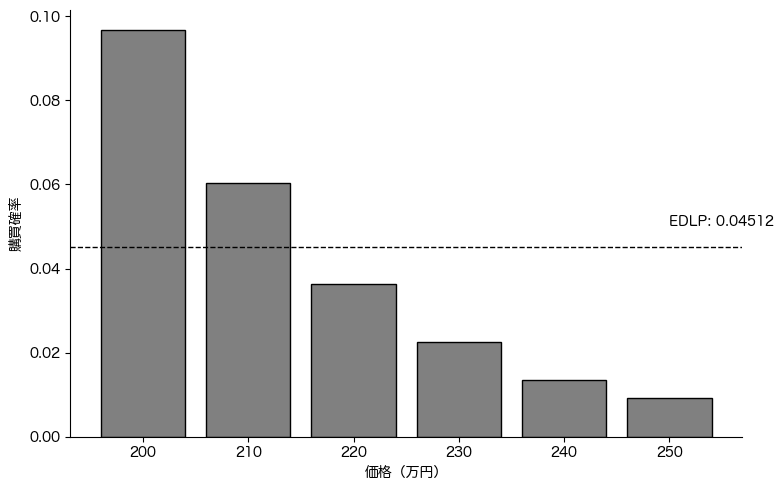

In [14]:
# 価格ごとの購買確率を図示（EDLP）
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(result_df_edlp['price'] * 100, result_df_edlp['prob_buy_baseline'],
       color='grey', edgecolor='black', width=8)
ax.axhline(y=prob_buy_edlp200, color='black', linewidth=1.0, linestyle='--')
ax.annotate(f'EDLP: {prob_buy_edlp200:.5f}',
            xy=(250, prob_buy_edlp200 + 0.005), fontsize=10)

ax.set_xlabel('価格（万円）')
ax.set_ylabel('購買確率')
ax.set_xticks(np.arange(200, 260, 10))
ax.set_ylim(bottom=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(output_dir / 'fig7_1_Counter1_EDLP.png', dpi=150)
plt.show()


## 反実仮想分析2: 永続的・一時的な値下げ

シナリオ1: ベースライン
シナリオ2: 10万円の永続的な値下げ
シナリオ3: 10万円の一時的な値下げ

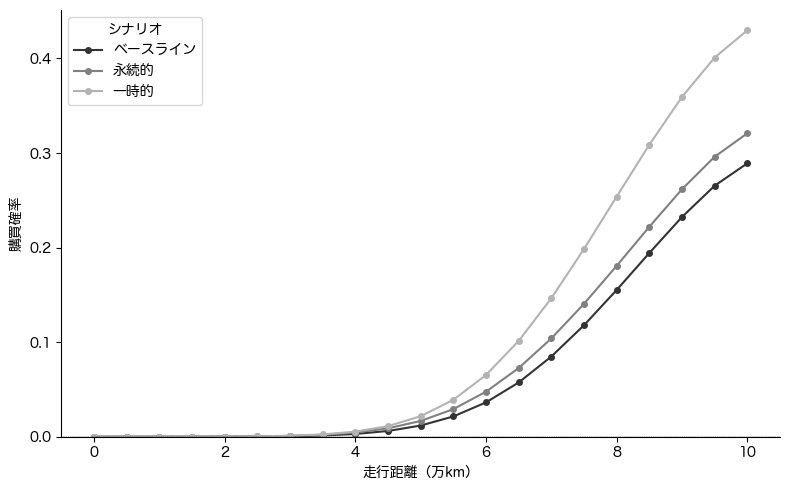

In [15]:
# シナリオ2: 永続的な値下げ
state_df_discount = state_df.copy()
state_df_discount['price'] = state_df_discount['price'] - 0.1
CCP_dict['Permanent'] = policy_operator_nfxp(theta_nfxp, beta, G, state_df_discount)

# シナリオ3: 一時的な値下げ
U_discount = flow_utility(theta_nfxp, state_df_discount)
V_baseline = contraction_nfxp(theta_nfxp, beta, G, state_df)
CV_temporary = U_discount + beta * np.column_stack([G[:, :, 0] @ V_baseline, G[:, :, 1] @ V_baseline])
CCP_dict['Temporary'] = np.exp(CV_temporary) / np.sum(np.exp(CV_temporary), axis=1, keepdims=True)

# 220万円での購買確率を図示
mask_220 = state_df['price'] == 2.2
scenarios = {
    'ベースライン': CCP_dict['Baseline'][mask_220.values, 1],
    '永続的': CCP_dict['Permanent'][mask_220.values, 1],
    '一時的': CCP_dict['Temporary'][mask_220.values, 1]
}

fig, ax = plt.subplots(figsize=(8, 5))
mileage_220 = state_df.loc[mask_220, 'mileage'].values * 100
colors = {'ベースライン': '0.2', '永続的': '0.5', '一時的': '0.7'}

for label, prob in scenarios.items():
    ax.plot(mileage_220, prob, marker='o', markersize=4, label=label, color=colors[label])

ax.set_xlabel('走行距離（万km）')
ax.set_ylabel('購買確率')
ax.set_xticks(np.arange(0, 11, 2))
ax.set_ylim(bottom=0)
ax.axhline(y=0, linestyle='--', color='black', linewidth=0.3)
ax.legend(title='シナリオ')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(output_dir / 'Counter2_CCP_mile.png', dpi=150)
plt.show()


## 消費者の分布のシミュレーション（値下げ）

In [16]:
# 状態変数毎の消費者の分布
consumer_dist_obs = (data_gen.groupby('state_id').size() / len(data_gen)).reindex(
    np.arange(1, num_states + 1), fill_value=0).values

# 購買を考慮した遷移行列
def make_G_CCP(CCP, G_mat):
    """CCPで重み付けした遷移行列を構築"""
    return CCP[:, 0:1] * G_mat[:, :, 0] + CCP[:, 1:2] * G_mat[:, :, 1]

G_CCP_dict = {}
for scenario in ['Baseline', 'Permanent', 'Temporary']:
    G_CCP_dict[scenario] = make_G_CCP(CCP_dict[scenario], G)

# EDLP用の遷移行列
for p in price_states:
    key = f'edlp{int(round(p*100))}'
    G_CCP_dict[key] = make_G_CCP(CCP_dict[key], G_fixed_price)

# シミュレーション
num_consumer_sim = 1000
num_period_sim = 10
discount_scenarios = ['Baseline', 'Permanent', 'Temporary']

sim_results = {'period': np.arange(1, num_period_sim + 1)}

for scenario in discount_scenarios:
    dist_sim = np.zeros((num_period_sim, num_states))
    dist_sim[0] = consumer_dist_obs

    prob_buy_sim = np.zeros(num_period_sim)
    demand = np.zeros(num_period_sim)
    revenue = np.zeros(num_period_sim)

    for t in range(num_period_sim):
        if t == 0 and scenario == 'Temporary':
            # 初期のみ一時的値下げのCCPを使用
            if t < num_period_sim - 1:
                dist_sim[t + 1] = dist_sim[t] @ G_CCP_dict['Temporary']
            prob_buy_sim[t] = dist_sim[t] @ CCP_dict['Temporary'][:, 1]
            demand[t] = prob_buy_sim[t] * num_consumer_sim
            revenue[t] = np.sum(
                (state_df['price'].values - 0.1) * dist_sim[t]
                * CCP_dict['Temporary'][:, 1] * num_consumer_sim)
        else:
            sc_current = 'Baseline' if scenario == 'Temporary' else scenario
            if t < num_period_sim - 1:
                dist_sim[t + 1] = dist_sim[t] @ G_CCP_dict[sc_current]
            prob_buy_sim[t] = dist_sim[t] @ CCP_dict[sc_current][:, 1]
            demand[t] = prob_buy_sim[t] * num_consumer_sim
            discount_val = 0.1 if scenario == 'Permanent' else 0
            revenue[t] = np.sum(
                (state_df['price'].values - discount_val) * dist_sim[t]
                * CCP_dict[sc_current][:, 1] * num_consumer_sim)

    sim_results[f'prob_buy_{scenario}'] = prob_buy_sim
    sim_results[f'demand_{scenario}'] = demand
    sim_results[f'revenue_{scenario}'] = revenue

sim_df = pd.DataFrame(sim_results)
print("シミュレーション完了")
sim_df.head()


シミュレーション完了


,period,prob_buy_Baseline,demand_Baseline,revenue_Baseline,prob_buy_Permanent,demand_Permanent,revenue_Permanent,prob_buy_Temporary,demand_Temporary,revenue_Temporary
0,1,0.027855,27.855091,61.066683,0.033054,33.053739,69.255421,0.044571,44.570513,93.799197
1,2,0.028792,28.792104,63.097738,0.033520,33.520361,70.210167,0.026605,26.605187,58.319690
2,3,0.029793,29.793351,65.282749,0.034136,34.135973,71.487404,0.027958,27.958328,61.251258
3,4,0.030894,30.894133,67.690126,0.034885,34.885338,73.048550,0.029269,29.268998,64.112106
4,5,0.032042,32.041564,70.205035,0.035694,35.693734,74.739404,0.030583,30.582866,66.990198


### 値下げの効果

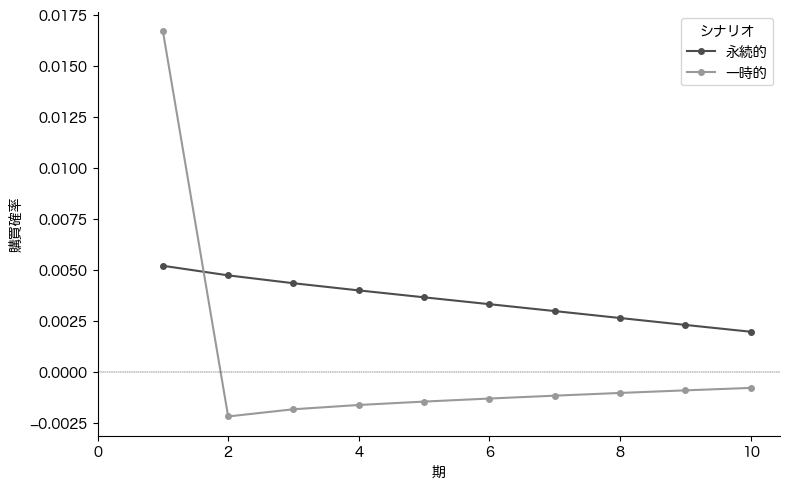

In [17]:
# 購買確率の変化
fig, ax = plt.subplots(figsize=(8, 5))

period = sim_df['period'].values
perm_change = sim_df['prob_buy_Permanent'] - sim_df['prob_buy_Baseline']
temp_change = sim_df['prob_buy_Temporary'] - sim_df['prob_buy_Baseline']

ax.plot(period, perm_change, marker='o', markersize=4, color='0.3', label='永続的')
ax.plot(period, temp_change, marker='o', markersize=4, color='0.6', label='一時的')
ax.axhline(y=0, linestyle='--', color='black', linewidth=0.3)

ax.set_xlabel('期')
ax.set_ylabel('購買確率')
ax.set_xticks(np.arange(0, 11, 2))
ax.legend(title='シナリオ')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(output_dir / 'fig7_2_Counter2_sim_choice_change.png', dpi=150)
plt.show()


## 需要と収入の計算

### EDLPのシミュレーション

In [18]:
# EDLP: 消費者分布（走行距離のみ）
consumer_dist_obs_edlp = (data_gen.groupby('mileage_id').size() / len(data_gen)).reindex(
    np.arange(1, num_mileage_states + 1), fill_value=0).values

edlp_results = {'period': np.arange(1, num_period_sim + 1)}

for fixed_price in price_states:
    key = f'edlp{int(round(fixed_price*100))}'
    n_mile = num_mileage_states
    dist_sim = np.zeros((num_period_sim, n_mile))
    dist_sim[0] = consumer_dist_obs_edlp

    prob_buy_sim = np.zeros(num_period_sim)
    demand = np.zeros(num_period_sim)
    revenue = np.zeros(num_period_sim)

    for t in range(num_period_sim):
        if t < num_period_sim - 1:
            dist_sim[t + 1] = dist_sim[t] @ G_CCP_dict[key]
        prob_buy_sim[t] = dist_sim[t] @ CCP_dict[key][:, 1]
        demand[t] = prob_buy_sim[t] * num_consumer_sim
        revenue[t] = fixed_price * prob_buy_sim[t] * num_consumer_sim

    edlp_results[f'demand_{key}'] = demand
    edlp_results[f'revenue_{key}'] = revenue

edlp_df = pd.DataFrame(edlp_results)

# 統合
sim_df = sim_df.merge(edlp_df, on='period')
print("EDLPシミュレーション完了")


EDLPシミュレーション完了


### 需要と収入の推移

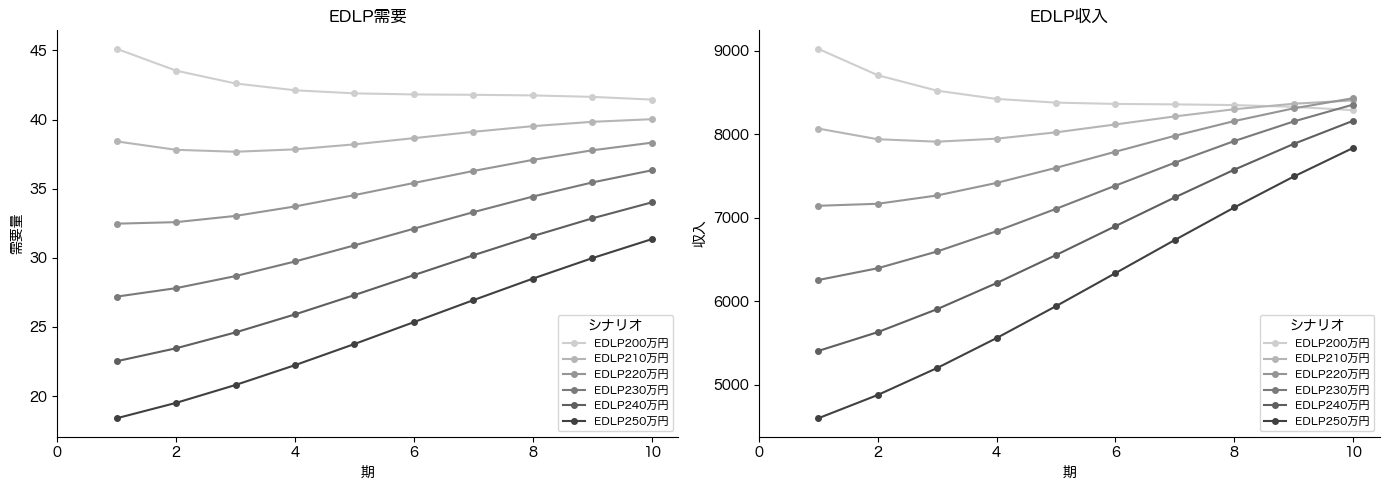

In [19]:
# EDLP需要の推移
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# EDLP 需要
ax = axes[0]
for i, p in enumerate(price_states):
    key = f'demand_edlp{int(round(p*100))}'
    ax.plot(sim_df['period'], sim_df[key], marker='o', markersize=4,
            color=plt.cm.Greys(0.3 + 0.1 * i), label=f'EDLP{int(round(p*100))}万円')
ax.set_xlabel('期')
ax.set_ylabel('需要量')
ax.set_xticks(np.arange(0, 11, 2))
ax.legend(title='シナリオ', fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('EDLP需要')

# EDLP 収入
ax = axes[1]
for i, p in enumerate(price_states):
    key = f'revenue_edlp{int(round(p*100))}'
    ax.plot(sim_df['period'], sim_df[key] * 100, marker='o', markersize=4,
            color=plt.cm.Greys(0.3 + 0.1 * i), label=f'EDLP{int(round(p*100))}万円')
ax.set_xlabel('期')
ax.set_ylabel('収入')
ax.set_xticks(np.arange(0, 11, 2))
ax.legend(title='シナリオ', fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('EDLP収入')

plt.tight_layout()
plt.savefig(output_dir / 'Counter2_sim_demand_revenue_EDLP.png', dpi=150)
plt.show()


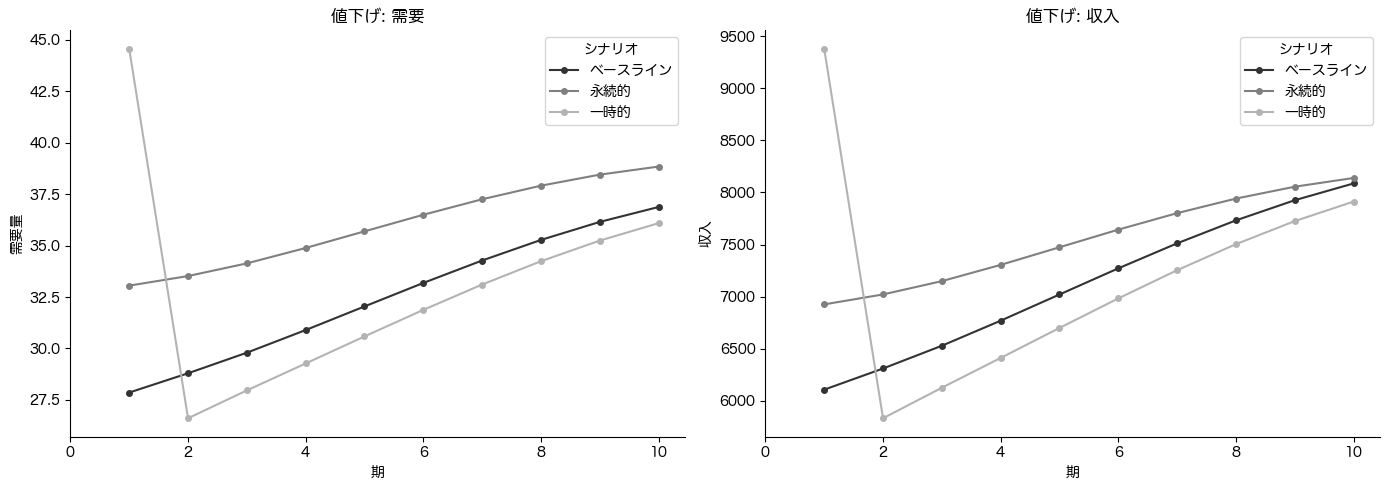

In [20]:
# 値下げ: 需要の推移
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
colors = {'Baseline': '0.2', 'Permanent': '0.5', 'Temporary': '0.7'}
labels = {'Baseline': 'ベースライン', 'Permanent': '永続的', 'Temporary': '一時的'}
for sc in discount_scenarios:
    ax.plot(sim_df['period'], sim_df[f'demand_{sc}'], marker='o', markersize=4,
            color=colors[sc], label=labels[sc])
ax.set_xlabel('期')
ax.set_ylabel('需要量')
ax.set_xticks(np.arange(0, 11, 2))
ax.legend(title='シナリオ')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('値下げ: 需要')

# 値下げ: 収入の推移
ax = axes[1]
for sc in discount_scenarios:
    ax.plot(sim_df['period'], sim_df[f'revenue_{sc}'] * 100, marker='o', markersize=4,
            color=colors[sc], label=labels[sc])
ax.set_xlabel('期')
ax.set_ylabel('収入')
ax.set_xticks(np.arange(0, 11, 2))
ax.legend(title='シナリオ')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('値下げ: 収入')

plt.tight_layout()
plt.savefig(output_dir / 'Counter2_sim_demand_revenue_down.png', dpi=150)
plt.show()


### 累積需要

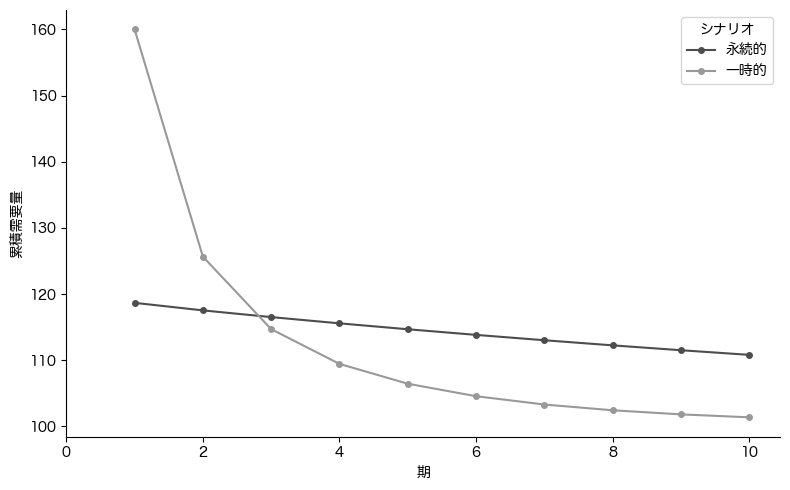

In [21]:
# 累積需要
fig, ax = plt.subplots(figsize=(8, 5))

cum_baseline = np.cumsum(sim_df['demand_Baseline'])
cum_permanent = np.cumsum(sim_df['demand_Permanent'])
cum_temporary = np.cumsum(sim_df['demand_Temporary'])

# ベースライン=100とした累積需要
ax.plot(sim_df['period'], cum_permanent / cum_baseline * 100, marker='o',
        markersize=4, color='0.3', label='永続的')
ax.plot(sim_df['period'], cum_temporary / cum_baseline * 100, marker='o',
        markersize=4, color='0.6', label='一時的')

ax.set_xlabel('期')
ax.set_ylabel('累積需要量')
ax.set_xticks(np.arange(0, 11, 2))
ax.legend(title='シナリオ')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(output_dir / 'Counter2_sim_cumdemand_down_100.png', dpi=150)
plt.show()


### 合計の需要と収入

In [22]:
# 合計需要と割引現在価値の収入
beta_discount = beta ** np.arange(num_period_sim)

all_scenarios = discount_scenarios + [f'edlp{int(round(p*100))}' for p in price_states]
summary_rows = []

for sc in all_scenarios:
    total_demand = sim_df[f'demand_{sc}'].sum()
    total_revenue = np.sum(sim_df[f'revenue_{sc}'].values * beta_discount) / 100  # 億円
    per_rev = total_revenue / total_demand * 10000 if total_demand > 0 else 0  # 万円
    summary_rows.append({'scenario': sc, 'demand': total_demand,
                         'revenue': total_revenue, 'per_rev': per_rev})

summary_df = pd.DataFrame(summary_rows)
print("シナリオ毎の需要と収入:")
print(summary_df.to_string(index=False))

with open(output_dir / 'tab7_2_compare_scenario.txt', 'w') as f:
    f.write(summary_df.to_string(index=False))


シナリオ毎の需要と収入:
 scenario     demand  revenue    per_rev
 Baseline 325.141872 5.641725 173.515807
Permanent 360.251320 6.006689 166.736075
Temporary 329.540951 5.748862 174.450600
  edlp200 423.726030 6.823010 161.024090
  edlp210 387.122177 6.506533 168.074405
  edlp220 351.235563 6.148389 175.050289
  edlp230 315.960473 5.749084 181.955796
  edlp240 281.192912 5.308811 188.796034
  edlp250 246.852143 4.827892 195.578275
